<a href="https://colab.research.google.com/github/niveditha04-yellanuru/AI-Internship-Project/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Card Fraud Detection using Python

End-to-end data analysis and machine learning project.

# **Step 1: Import Libraries**

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


# Step 2: Load **Dataset**

In [3]:

# Load dataset
df = pd.read_csv("Credit Card Fraud Risk Analysis.csv")
df.head()


,Transaction ID,Customer Name,Merchant Name,Transaction Date,Transaction Amount (INR),Fraud Risk,Fraud Type,State,Card Type,Bank,IsFraud,Fraud Score,Transaction Category,Merchant Location
0,17797619,Pihu Manne,Uber,2024-11-10,11673,Medium,Card Not Present,Telangana,Rupay,ICICI Bank,0,57,Transportation,Bangalore
1,50040671,Hiran Vaidya,Zomato,2024-05-20,16594,Medium,Phishing,Maharashtra,Amex,SBI,0,10,Groceries,Bangalore
2,88177651,Shalv Vasa,Myntra,2024-05-28,23347,Medium,Card Skimming,Uttar Pradesh,Visa,HDFC Bank,0,55,Transportation,Ahmedabad
3,24228305,Taran Shanker,Lifestyle,2024-01-09,20753,Low,Card Skimming,Kerala,Visa,Federal Bank,0,30,E-commerce,Lucknow
4,87307869,Shanaya Kara,Tata Cliq,2024-07-27,6432,Low,Card Skimming,Delhi,Amex,SBI,0,86,Electronics,Hyderabad


# Step 3: Basic Data **Understanding**

In [4]:

# Dataset overview
df.shape


(1000, 14)

In [5]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Transaction ID            1000 non-null   int64 
 1   Customer Name             1000 non-null   object
 2   Merchant Name             1000 non-null   object
 3   Transaction Date          1000 non-null   object
 4   Transaction Amount (INR)  1000 non-null   int64 
 5   Fraud Risk                1000 non-null   object
 6   Fraud Type                1000 non-null   object
 7   State                     1000 non-null   object
 8   Card Type                 1000 non-null   object
 9   Bank                      1000 non-null   object
 10  IsFraud                   1000 non-null   int64 
 11  Fraud Score               1000 non-null   int64 
 12  Transaction Category      1000 non-null   object
 13  Merchant Location         1000 non-null   object
dtypes: int64(4), object(10)
m

In [6]:

df.describe()


,Transaction ID,Transaction Amount (INR),IsFraud,Fraud Score
count,1.000000e+03,1000.000000,1000.000000,1000.000000
mean,5.486023e+07,12226.843000,0.286000,53.179000
std,2.616482e+07,7106.084734,0.452115,25.723815
min,1.003645e+07,141.000000,0.000000,10.000000
25%,3.235345e+07,6218.000000,0.000000,29.000000
50%,5.379576e+07,11999.500000,0.000000,54.000000
75%,7.790521e+07,18207.750000,1.000000,76.000000
max,9.994398e+07,24993.000000,1.000000,95.000000


Step 4: **Check Missing Values**


In [7]:

# Missing values
df.isnull().sum()


,0
Transaction ID,0
Customer Name,0
Merchant Name,0
Transaction Date,0
Transaction Amount (INR),0
Fraud Risk,0
Fraud Type,0
State,0
Card Type,0
Bank,0


Step 5: **Fraud vs Non-Fraud Analysis**

In [9]:
# Fraud vs Non-Fraud
df['IsFraud'].value_counts()

,count
IsFraud,
0,714
1,286


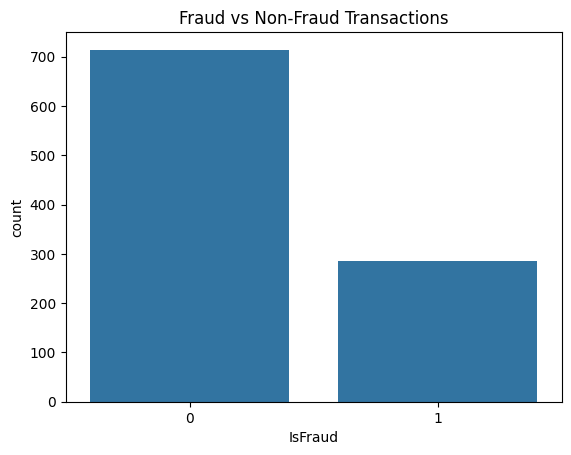

In [11]:

sns.countplot(x='IsFraud', data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

Step 6: **Feature Selection**

In [13]:

# Feature selection
# Drop non-numeric and irrelevant columns for X, and set 'IsFraud' as the target variable y
X = df.drop(['Transaction ID', 'Customer Name', 'Merchant Name', 'Transaction Date', 'Fraud Risk', 'Fraud Type', 'State', 'Card Type', 'Bank', 'Transaction Category', 'Merchant Location', 'IsFraud'], axis=1)
y = df['IsFraud']

Step 7: **Train-Test Split**

In [21]:

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


Step 8: **Model Building (Logistic Regression)**

In [15]:

# Model training
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

Step 9: **Predictions**

In [16]:

# Predictions
y_pred = model.predict(X_test)


Step 10: **Model Evaluation**

In [17]:

# Evaluation
accuracy_score(y_test, y_pred)


0.7133333333333334

In [18]:

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.71      1.00      0.83       214
           1       0.00      0.00      0.00        86

    accuracy                           0.71       300
   macro avg       0.36      0.50      0.42       300
weighted avg       0.51      0.71      0.59       300



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


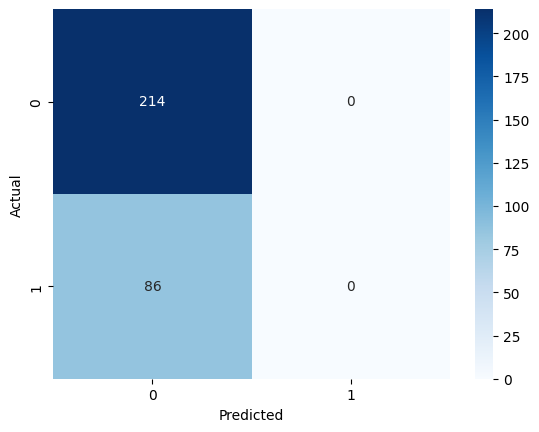

In [19]:

conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Step 11: **Business Insight**

In [22]:
fraud_count = df['IsFraud'].value_counts()
fraud_percentage = (fraud_count[1] / fraud_count.sum()) * 100
print(f"Fraud transactions percentage: {fraud_percentage:.2f}%")

Fraud transactions percentage: 28.60%


Save file


In [23]:
# Create a DataFrame with actual and predicted values
results = pd.DataFrame({
    "Actual_Class": y_test,
    "Predicted_Class": y_pred
})

# Save to CSV
results.to_csv("fraud_prediction_results.csv", index=False)

print("Prediction file saved successfully")


Prediction file saved successfully
